In [1]:
import typing

import numpy as np
import matplotlib.pyplot as plt
from jaxtyping import Float, Int
from scipy.optimize import linprog

import muutils.dbg
muutils.dbg.DBG_TENSOR_ARRAY_SUMMARY_DEFAULTS["sparkline_logy"] = True
from muutils.dbg import dbg_tensor
from muutils.tensor_info import array_summary

from attention_motifs.util import plot_figs, load_activations, get_single_attn_pattern
from attention_motifs.transition_tensor import transition_tensor, tt_fig


In [2]:
MODEL_NAME: str = "pythia-14m"
MODEL_CFG: dict
PROMPTS: list[dict]
ACTIVATIONS: list[np.lib.npyio.NpzFile]
MODEL_CFG, PROMPTS, ACTIVATIONS = load_activations(MODEL_NAME)

In [3]:
_idxs, _tt, _res = transition_tensor(
	get_single_attn_pattern(0, 0, 0, activations=ACTIVATIONS),
	exact=20,
	approx_l10=4.0,
	approx_pts=20,
)
dbg_tensor(_idxs)
dbg_tensor(_tt)
dbg_tensor(_res)

print()

[ /home/miv/projects/attn/attention-motifs/attention_motifs/transition_tensor.py:141 ] res_resampled: μ=0.09 σ=0.26 x̃=0.01 R=[0.00,1.41] ℙ=|█▄▂▂▃▃▄| shape=(40,82) dtype=float32
[ <ipykernel>:7 ] _idxs: μ=899.38 σ=2097.03 x̃=19.50 R=[0.00,10000.00] ℙ=|█▂▁▁ ▁▁| shape=40 dtype=int64
[ <ipykernel>:8 ] _tt: μ=0.01 σ=0.10 x̃=0.00 R=[0.00,1.00] ℙ=|█▃▃▃▃▃▄| shape=(40,82,82) dtype=float32
[ <ipykernel>:9 ] _res: μ=0.09 σ=0.26 x̃=0.01 R=[0.00,1.41] ℙ=|█▄▂▂▃▃▄| shape=(40,82) dtype=float32


In [4]:


def compute_r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    ss_res: float = np.sum((y_true - y_pred) ** 2)
    ss_tot: float = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else (1.0 if ss_res == 0 else 0.0)

def compute_envelope_params(
    x: list[float],
    y: list[float],
    envelope_type: str = "lower",
) -> tuple[float, float, float]:
    """Compute the parameters (slope, intercept) for an envelope or best-fit line and its R^2 measure.

    This function computes a line L(x) = m*x + b along with an R^2 measure of fit.
    It supports three modes based on the envelope_type parameter:
      - "lower": Computes the highest line that lies entirely below the points (i.e. m*x + b <= y for all x)
                 by maximizing m*x_mid + b, where x_mid = (min(x) + max(x)) / 2.
      - "upper": Computes the lowest line that lies entirely above the points (i.e. m*x + b >= y for all x)
                 by minimizing m*x_mid + b.
      - "bestfit": Computes the ordinary least-squares line of best fit for the data.

    # Parameters:
     - `x : list[float]`
         The x-values (assumed to be in increasing order).
     - `y : list[float]`
         The y-values corresponding to x.
     - `envelope_type : str`
         One of "lower", "upper", or "bestfit" indicating which line to compute.

    # Returns:
     - `Tuple[float, float, float]`
         A tuple (m, b, r2) where the line is given by L(x) = m*x + b and r2 is the coefficient of determination.
    
    # Raises:
     - `ValueError` : if the input lists are not of equal length, contain fewer than 3 points,
       or if envelope_type is not one of "lower", "upper", or "bestfit".
    """
    if len(x) != len(y) or len(x) < 3:
        raise ValueError("Input lists must have the same length and contain at least 3 points.")
    
    x_arr: np.ndarray = np.array(x, dtype=float)
    y_arr: np.ndarray = np.array(y, dtype=float)
    
    if envelope_type == "bestfit":
        # Ordinary least squares best-fit line.
        m: float
        b: float
        m, b = np.polyfit(x_arr, y_arr, 1)
        y_pred: np.ndarray = m * x_arr + b
        r2: float = compute_r2(y_arr, y_pred)
        return m, b, r2

    # For envelope constraints we compute the midpoint of x.
    x_min: float = np.min(x_arr)
    x_max: float = np.max(x_arr)
    x_mid: float = (x_min + x_max) / 2.0

    if envelope_type == "lower":
        # For lower envelope: maximize m*x_mid + b subject to m*x_i + b <= y_i.
        # This is equivalent to minimizing -m*x_mid - b.
        c: np.ndarray = np.array([-x_mid, -1.0])
        A_ub: np.ndarray = np.column_stack((x_arr, np.ones_like(x_arr)))
        b_ub: np.ndarray = y_arr.copy()
    elif envelope_type == "upper":
        # For upper envelope: minimize m*x_mid + b subject to m*x_i + b >= y_i.
        # Rewrite constraint: -m*x_i - b <= -y_i.
        c: np.ndarray = np.array([x_mid, 1.0])
        A_ub: np.ndarray = -np.column_stack((x_arr, np.ones_like(x_arr)))
        b_ub: np.ndarray = -y_arr.copy()
    else:
        raise ValueError("envelope_type must be 'lower', 'upper', or 'bestfit'.")

    res = linprog(c=c, A_ub=A_ub, b_ub=b_ub, method='highs')
    if not res.success:
        raise ValueError("Linear programming failed: " + res.message)
    
    m: float = res.x[0]
    b: float = res.x[1]
    y_pred: np.ndarray = m * x_arr + b
    r2: float = compute_r2(y_arr, y_pred)
    return m, b, r2


def linear(x: Float[np.ndarray, "len(x)"], m: float, b: float) -> Float[np.ndarray, "len(x)"]:
    """Compute the linear function L(x) = m*x + b."""
    return m * x + b

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 0, 0)
[ /home/miv/projects/attn/attention-motifs/attention_motifs/transition_tensor.py:141 ] res_resampled: μ=0.04 σ=0.17 x̃=0.00 R=[0.00,1.41] ℙ=|█▃▁▂▃▂▃| shape=(100,82) dtype=float32
[ <ipykernel>:55 ] indices_adjusted: μ=15.45 σ=4.14 x̃=16.00 R=[0.00,20.00] ℙ=|▂▂▂▃▅▇█| shape=82 dtype=float64
[ <ipykernel>:56 ] indices_adjusted_l10: μ=1.17 σ=0.17 x̃=1.20 R=[0.30,1.30] ℙ=|▁▂ ▁▂▅█| shape=81 dtype=float64


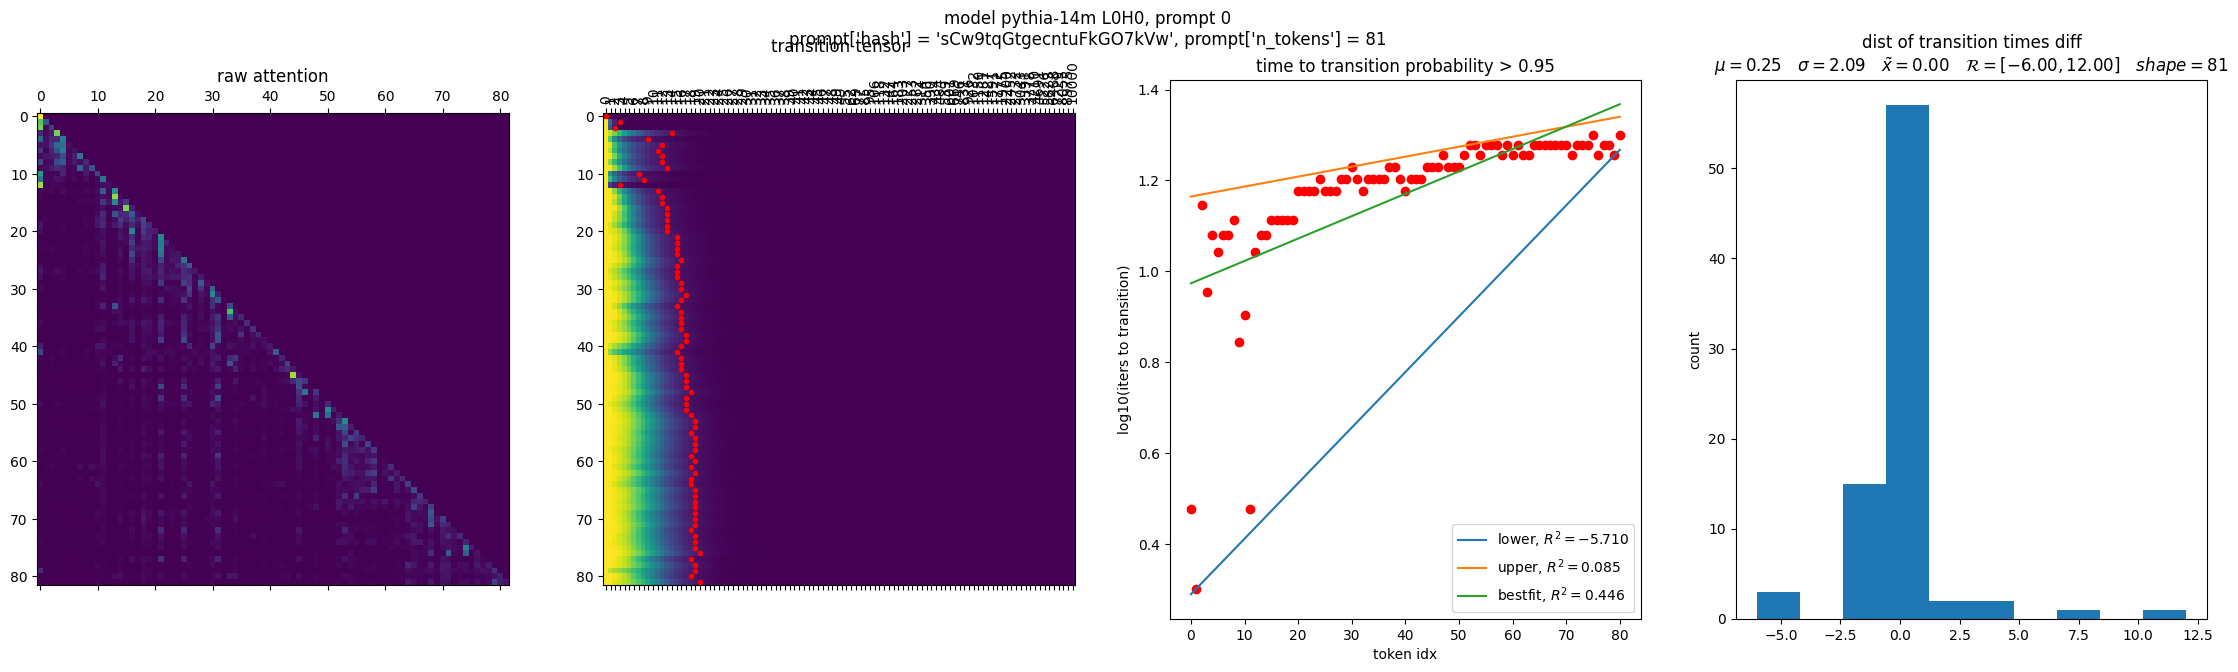

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 1, 0)
[ /home/miv/projects/attn/attention-motifs/attention_motifs/transition_tensor.py:141 ] res_resampled: μ=0.05 σ=0.16 x̃=0.01 R=[0.00,1.41] ℙ=|█▄▃▂▁▂▃| shape=(100,82) dtype=float32
[ <ipykernel>:55 ] indices_adjusted: μ=197.55 σ=107.23 x̃=227.00 R=[0.00,350.00] ℙ=|▆▅▅▆▅█▆| shape=82 dtype=float64
[ <ipykernel>:56 ] indices_adjusted_l10: μ=2.16 σ=0.45 x̃=2.36 R=[0.70,2.54] ℙ=|▂▃▂▃▂▆█| shape=81 dtype=float64


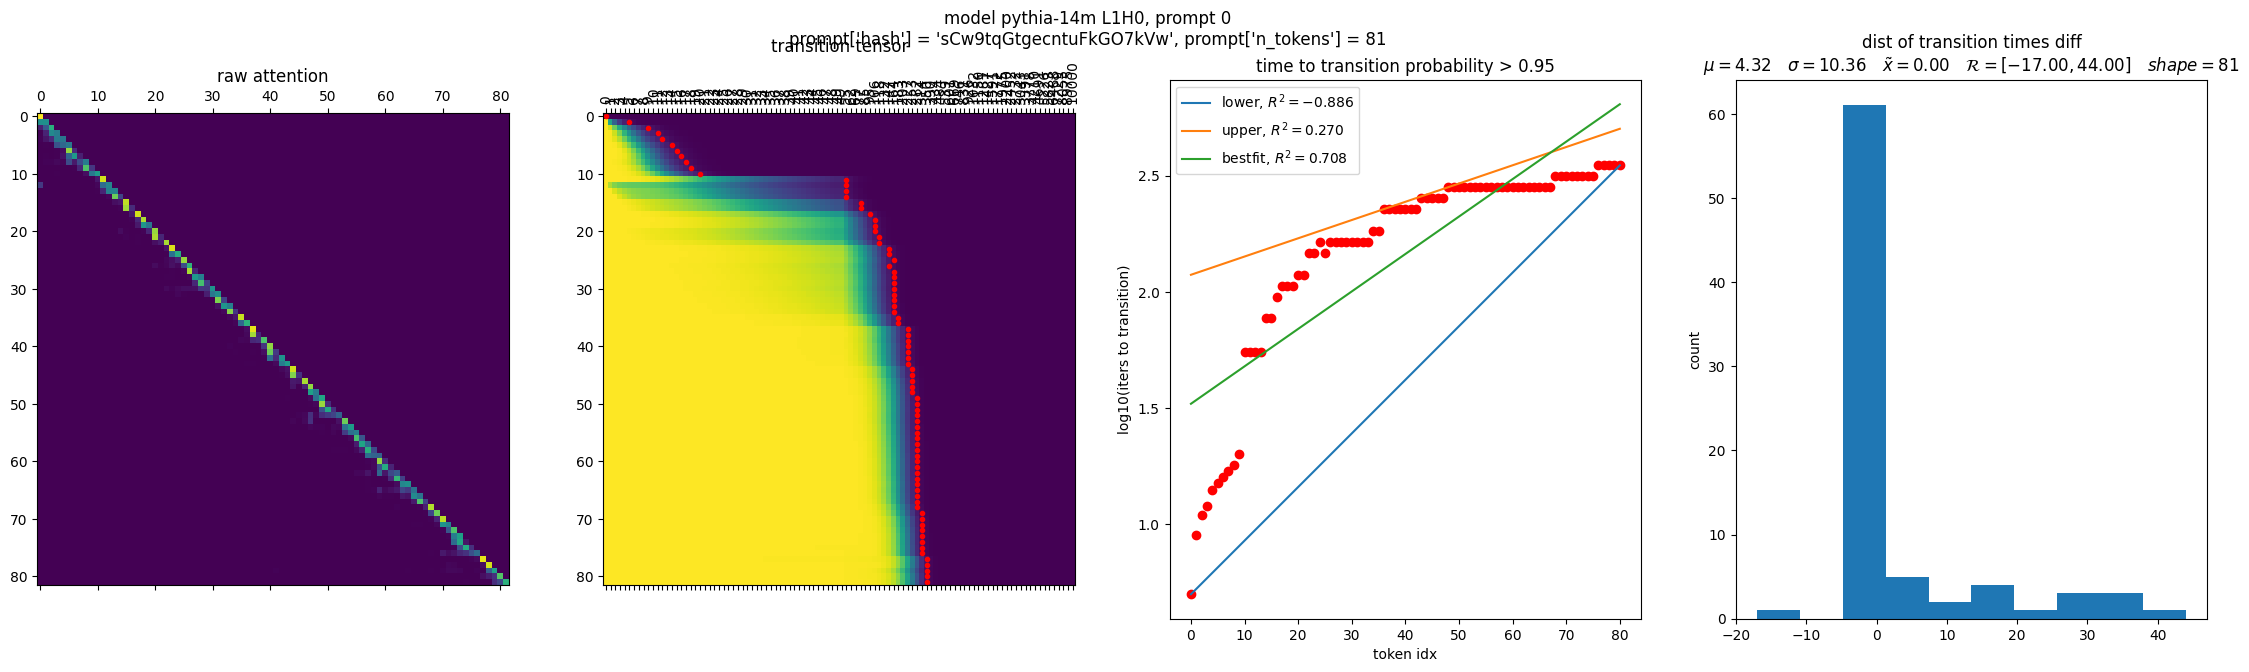

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 2, 0)
[ /home/miv/projects/attn/attention-motifs/attention_motifs/transition_tensor.py:141 ] res_resampled: μ=0.03 σ=0.17 x̃=0.00 R=[0.00,1.41] ℙ=|█▃ ▁▃▂▃| shape=(100,82) dtype=float32
[ <ipykernel>:55 ] indices_adjusted: μ=11.06 σ=1.80 x̃=11.00 R=[0.00,13.00] ℙ=|▁  ▂▃▇█| shape=82 dtype=float64
[ <ipykernel>:56 ] indices_adjusted_l10: μ=1.05 σ=0.06 x̃=1.04 R=[0.78,1.11] ℙ=|▁▁ ▃▅▆█| shape=81 dtype=float64


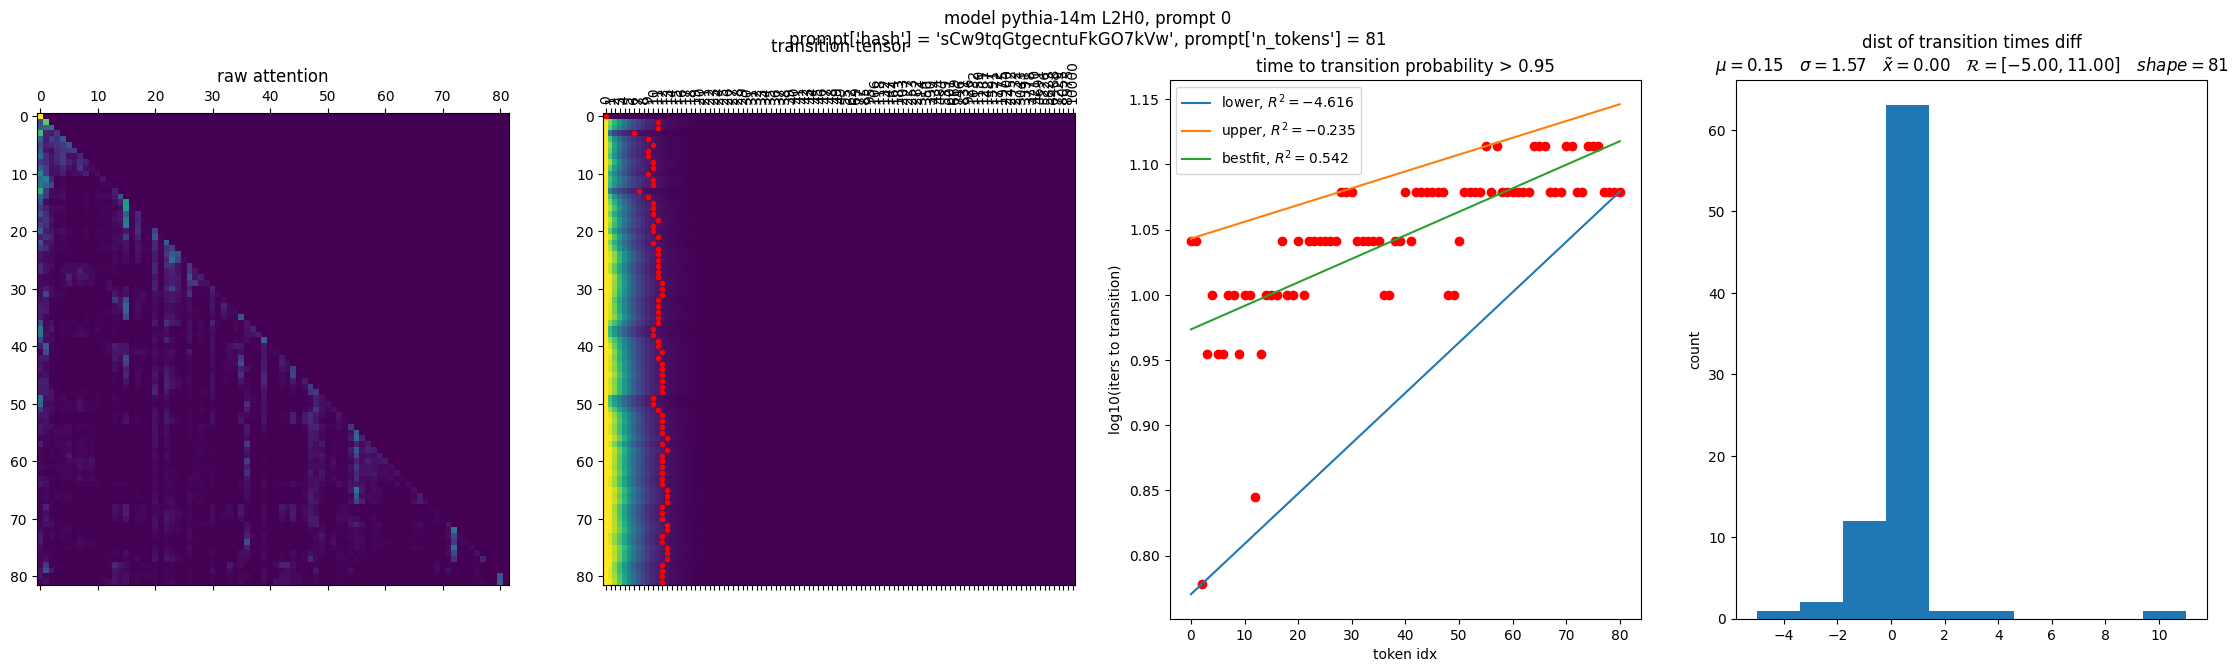

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 3, 0)
[ /home/miv/projects/attn/attention-motifs/attention_motifs/transition_tensor.py:141 ] res_resampled: μ=0.03 σ=0.19 x̃=0.00 R=[0.00,1.41] ℙ=|█▃▂▂▂▃▄| shape=(100,82) dtype=float32
[ <ipykernel>:55 ] indices_adjusted: μ=3.96 σ=1.38 x̃=4.00 R=[0.00,7.00] ℙ=|▁▃▅▅█▆▅| shape=82 dtype=float64
[ <ipykernel>:56 ] indices_adjusted_l10: μ=0.57 σ=0.18 x̃=0.60 R=[0.00,0.85] ℙ=|▃ ▅▅█▆▅| shape=81 dtype=float64


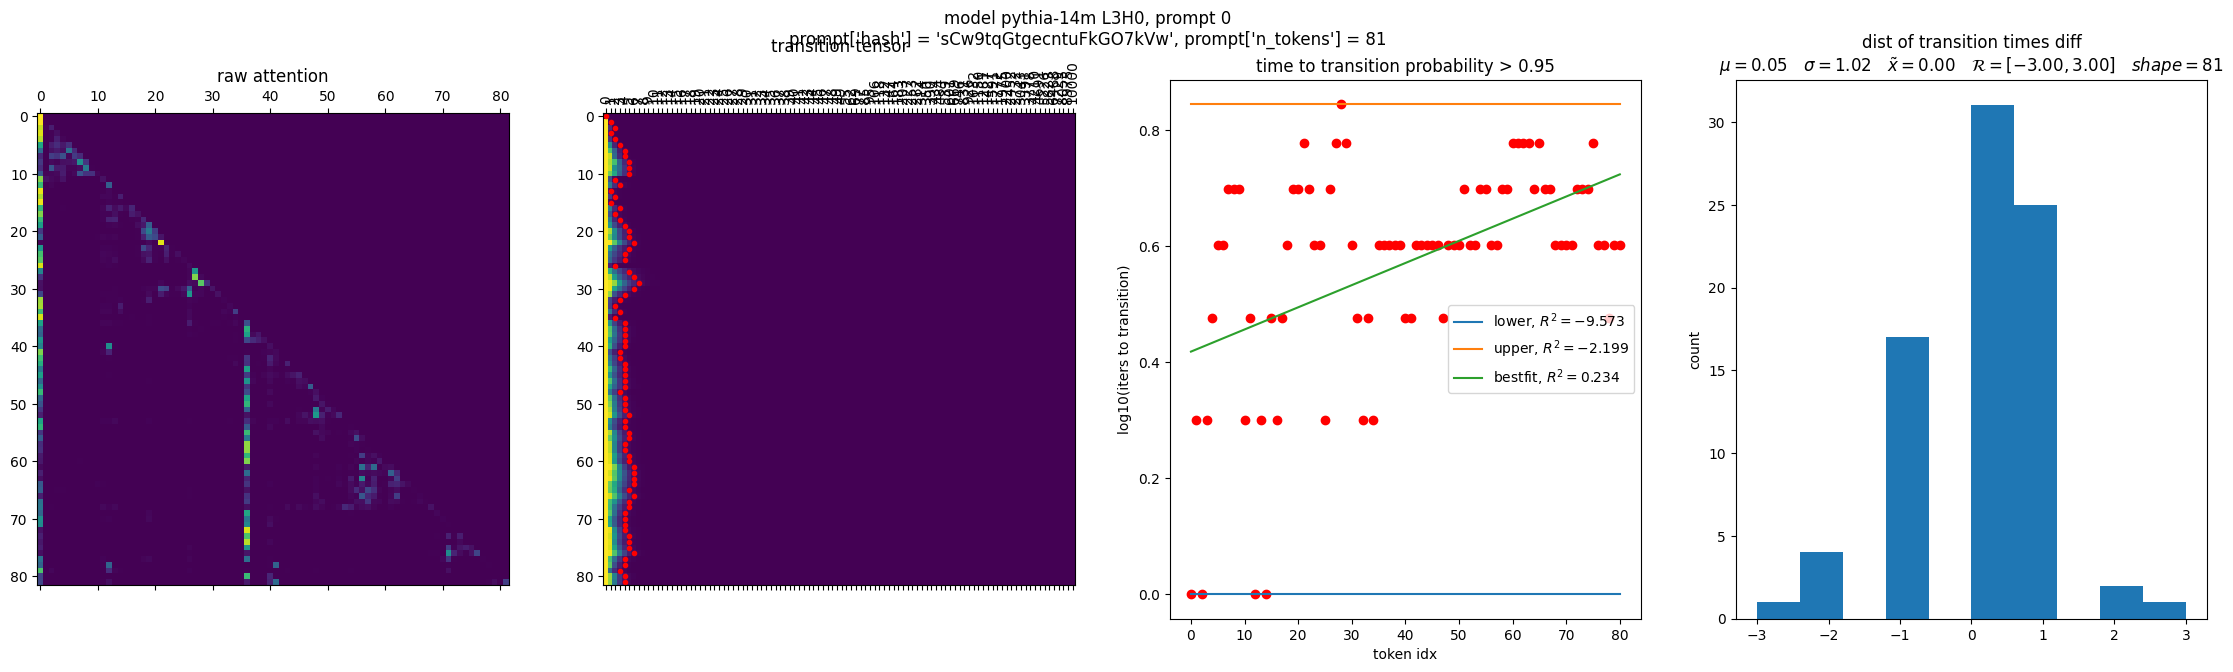

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 4, 0)
[ /home/miv/projects/attn/attention-motifs/attention_motifs/transition_tensor.py:141 ] res_resampled: μ=0.04 σ=0.22 x̃=0.00 R=[0.00,1.41] ℙ=|█▃▂▃▂▃▄| shape=(100,82) dtype=float32
[ <ipykernel>:55 ] indices_adjusted: μ=11.68 σ=17.51 x̃=5.00 R=[0.00,69.00] ℙ=|█▁▃▁  ▃| shape=82 dtype=float64
[ <ipykernel>:56 ] indices_adjusted_l10: μ=0.79 σ=0.44 x̃=0.70 R=[0.00,1.84] ℙ=|▃▆█▅▁▄▄| shape=81 dtype=float64


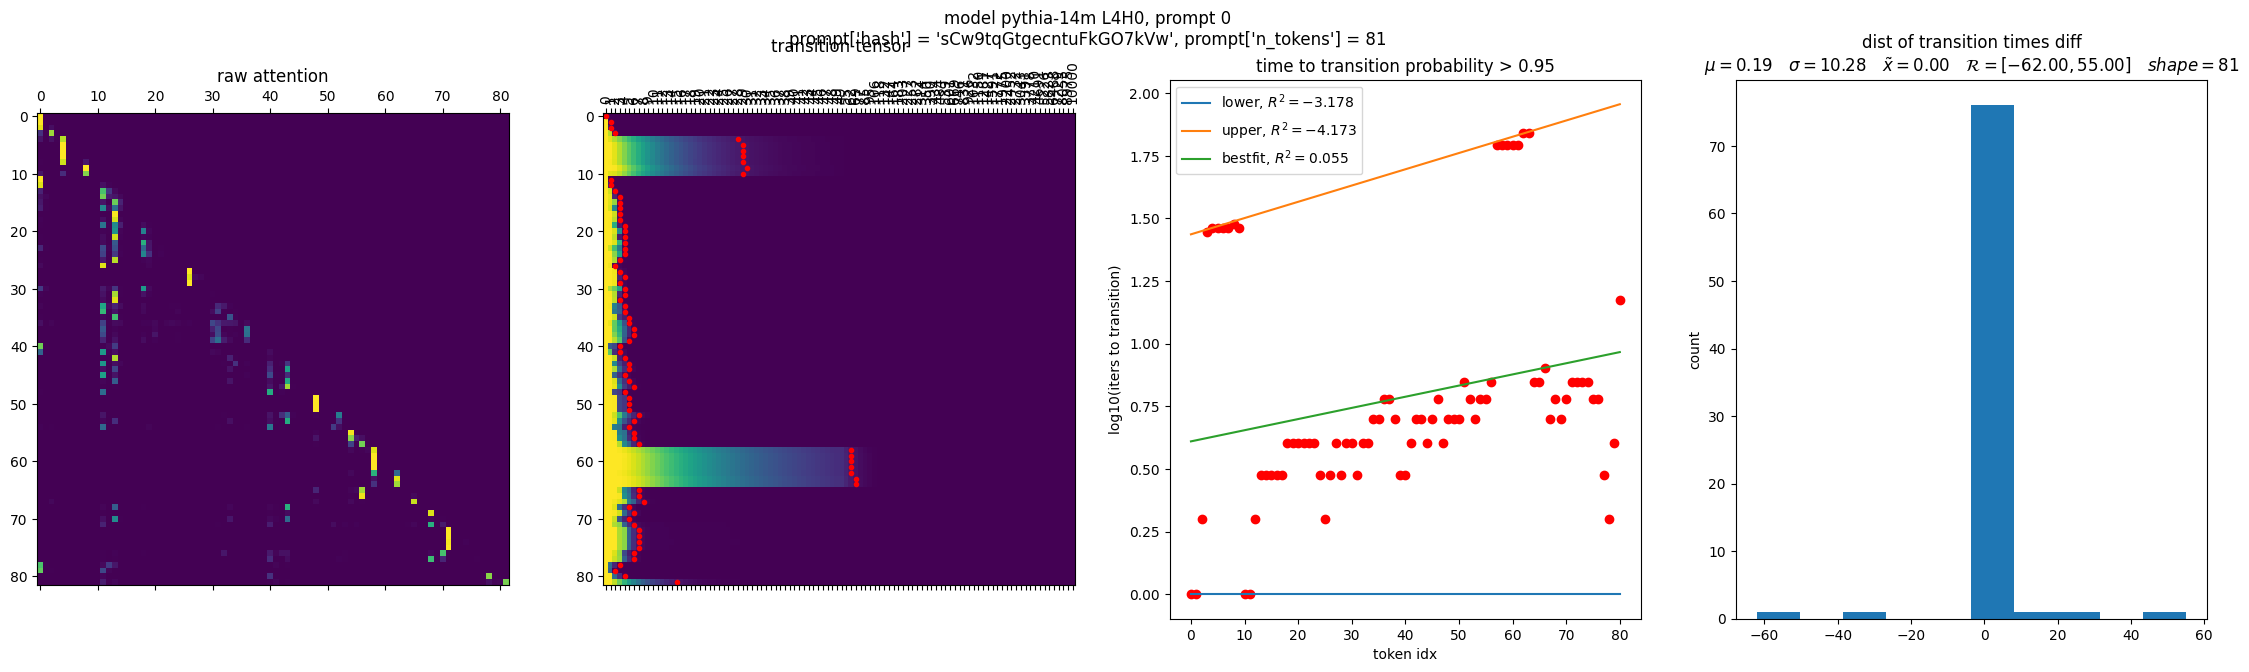

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 5, 0)
[ /home/miv/projects/attn/attention-motifs/attention_motifs/transition_tensor.py:141 ] res_resampled: μ=0.04 σ=0.23 x̃=0.00 R=[0.00,1.41] ℙ=|█▂▂▂ ▂▄| shape=(100,82) dtype=float32
[ <ipykernel>:55 ] indices_adjusted: μ=3170731709.22 σ=4653361956.84 x̃=4.00 R=[0.00,10000000000.00] ℙ=|█     ▆| shape=82 dtype=float64
[ <ipykernel>:56 ] indices_adjusted_l10: μ=3.46 σ=4.50 x̃=0.60 R=[0.00,10.00] ℙ=|█     ▆| shape=81 dtype=float64


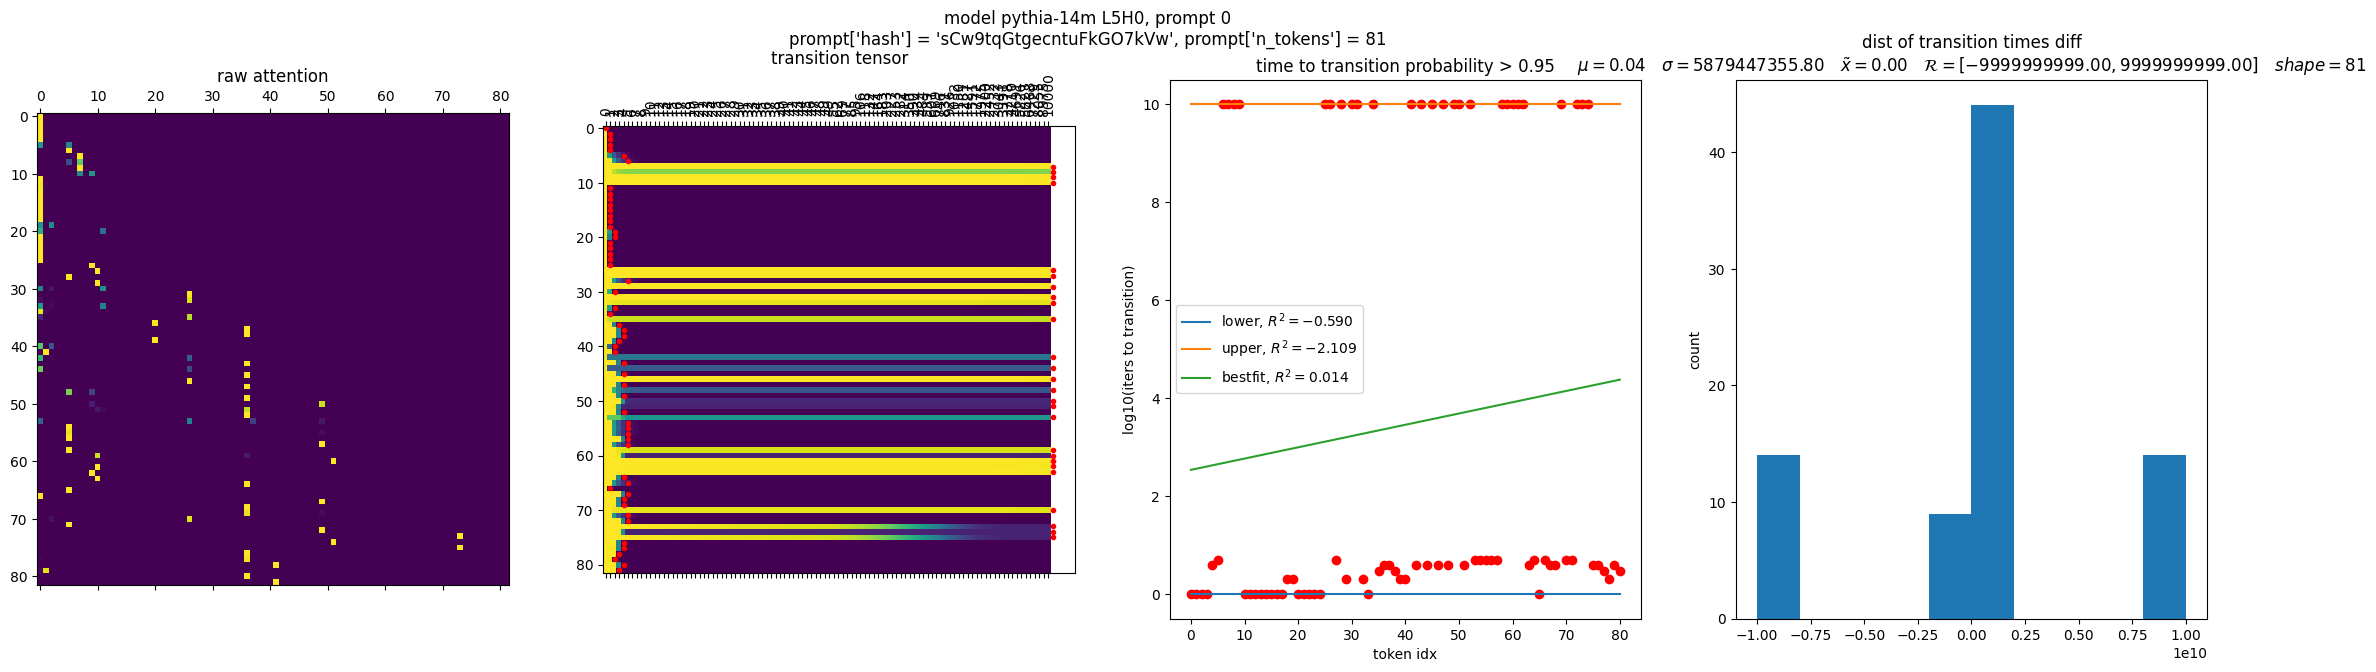

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 0, 0)
[ /home/miv/projects/attn/attention-motifs/attention_motifs/transition_tensor.py:141 ] res_resampled: μ=0.04 σ=0.17 x̃=0.01 R=[0.00,1.41] ℙ=|█▃▁▁▂▃▃| shape=(100,54) dtype=float32
[ <ipykernel>:55 ] indices_adjusted: μ=57.37 σ=19.19 x̃=62.00 R=[0.00,69.00] ℙ=|▃▁   ▁█| shape=54 dtype=float64
[ <ipykernel>:56 ] indices_adjusted_l10: μ=1.69 σ=0.37 x̃=1.79 R=[0.30,1.84] ℙ=|▂ ▁▁  █| shape=53 dtype=float64


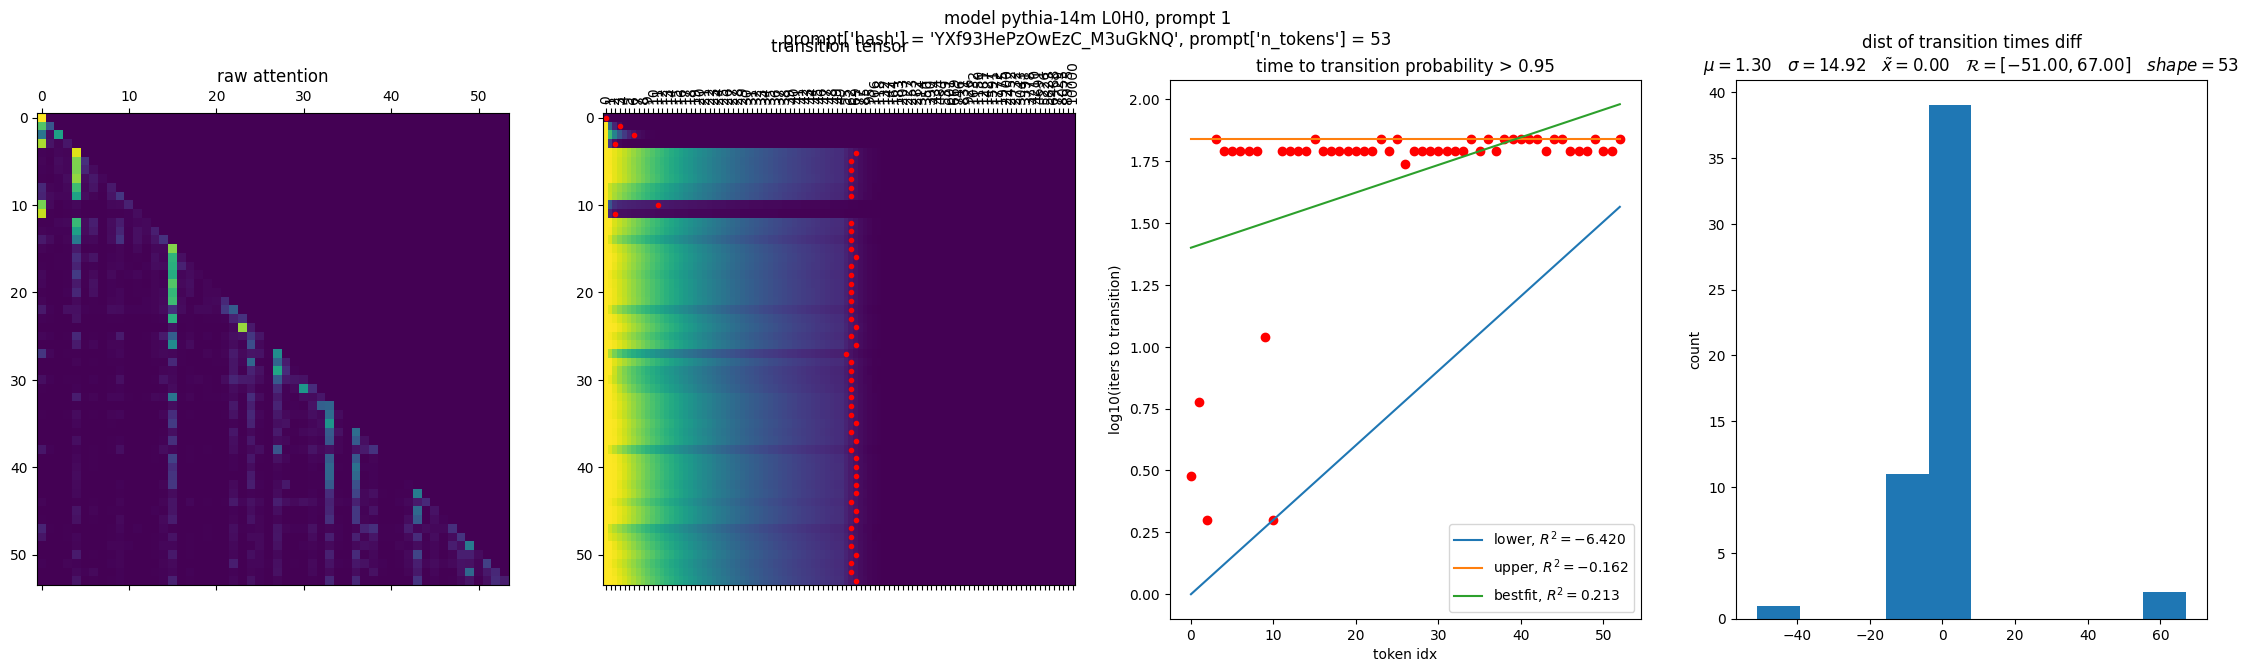

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 1, 0)
[ /home/miv/projects/attn/attention-motifs/attention_motifs/transition_tensor.py:141 ] res_resampled: μ=0.04 σ=0.15 x̃=0.01 R=[0.00,1.41] ℙ=|█▃▂▁▁▁▃| shape=(100,54) dtype=float32
[ <ipykernel>:55 ] indices_adjusted: μ=507.43 σ=228.03 x̃=601.00 R=[0.00,926.00] ℙ=|▅▄ ▄█▇▁| shape=54 dtype=float64
[ <ipykernel>:56 ] indices_adjusted_l10: μ=2.63 σ=0.33 x̃=2.78 R=[1.74,2.97] ℙ=|▄▁▁▃ █▆| shape=53 dtype=float64


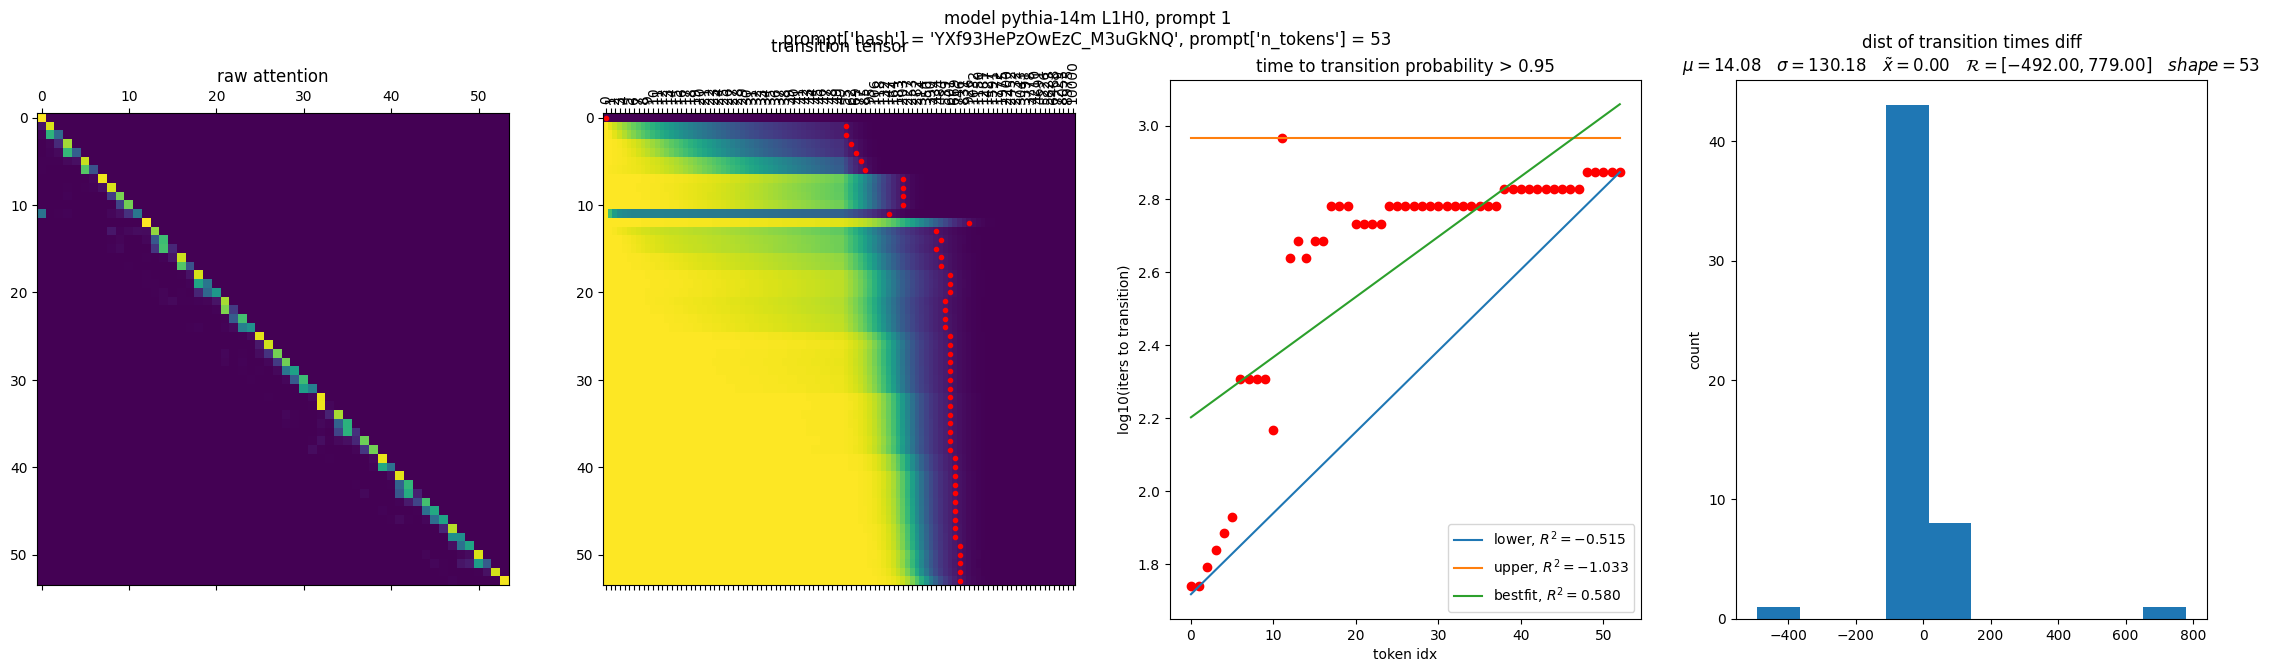

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 2, 0)
[ /home/miv/projects/attn/attention-motifs/attention_motifs/transition_tensor.py:141 ] res_resampled: μ=0.03 σ=0.17 x̃=0.00 R=[0.00,1.41] ℙ=|█▄▁▁▃▂▃| shape=(100,54) dtype=float32
[ <ipykernel>:55 ] indices_adjusted: μ=6.24 σ=1.84 x̃=7.00 R=[0.00,8.00] ℙ=|▁▁▃▄▁▅█| shape=54 dtype=float64
[ <ipykernel>:56 ] indices_adjusted_l10: μ=0.78 σ=0.14 x̃=0.85 R=[0.30,0.90] ℙ=|▁ ▃▄▁▅█| shape=53 dtype=float64


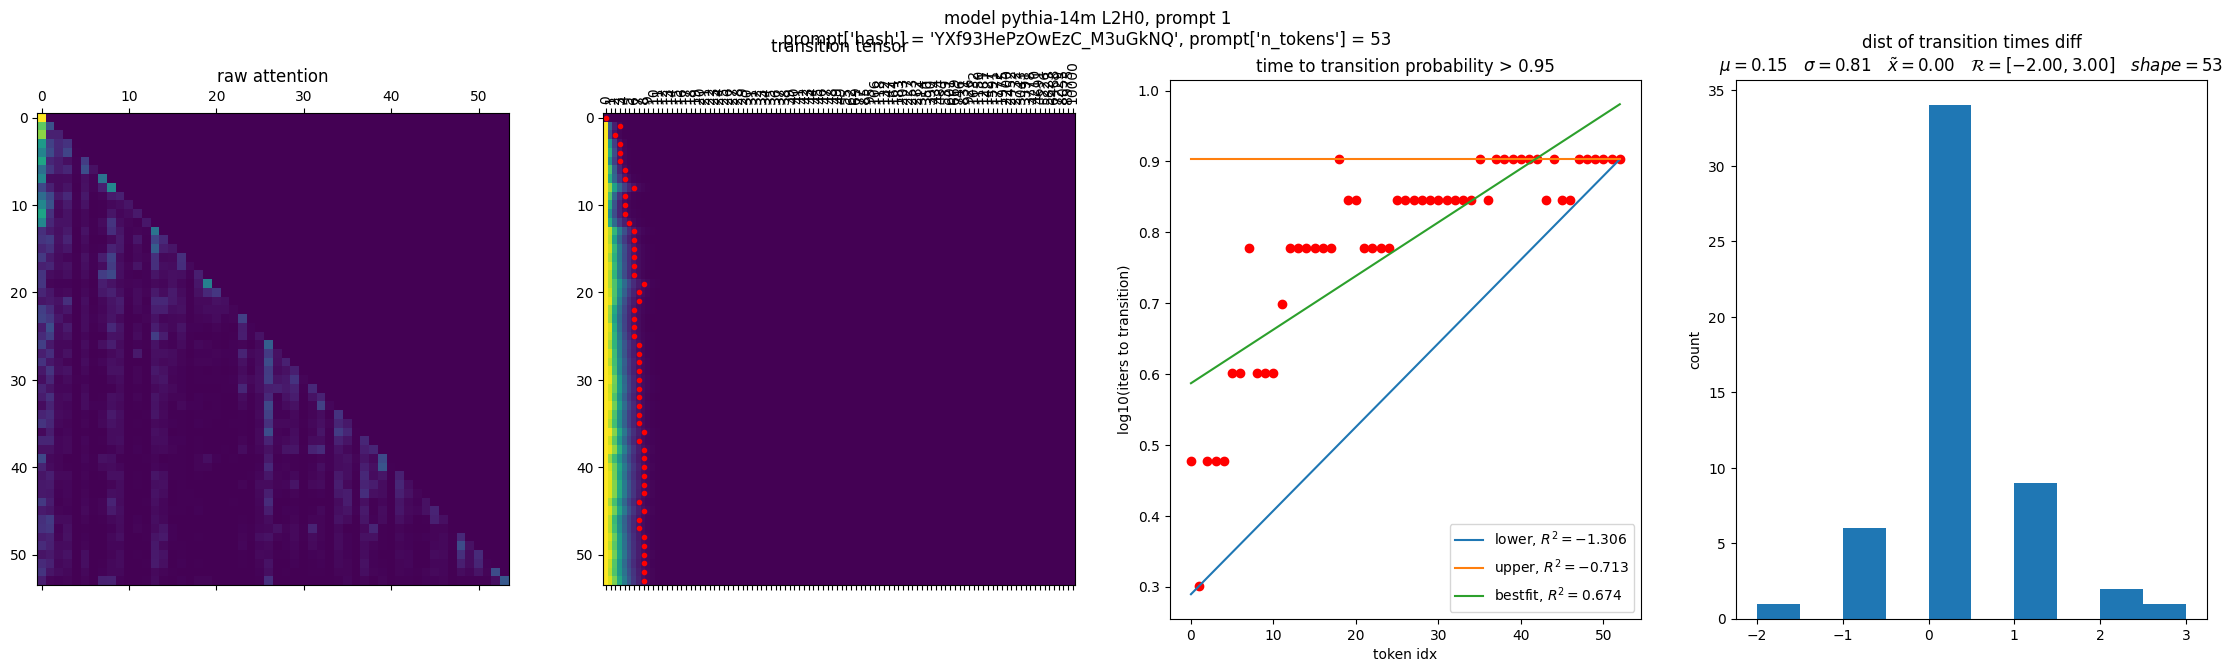

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 3, 0)
[ /home/miv/projects/attn/attention-motifs/attention_motifs/transition_tensor.py:141 ] res_resampled: μ=0.03 σ=0.19 x̃=0.00 R=[0.00,1.41] ℙ=|█▃▂▁▁▃▄| shape=(100,54) dtype=float32
[ <ipykernel>:55 ] indices_adjusted: μ=3.00 σ=1.22 x̃=3.00 R=[0.00,5.00] ℙ=|▁▅▆ ▆█▄| shape=54 dtype=float64
[ <ipykernel>:56 ] indices_adjusted_l10: μ=0.44 σ=0.20 x̃=0.48 R=[0.00,0.70] ℙ=|▄  ▆▆ █| shape=53 dtype=float64


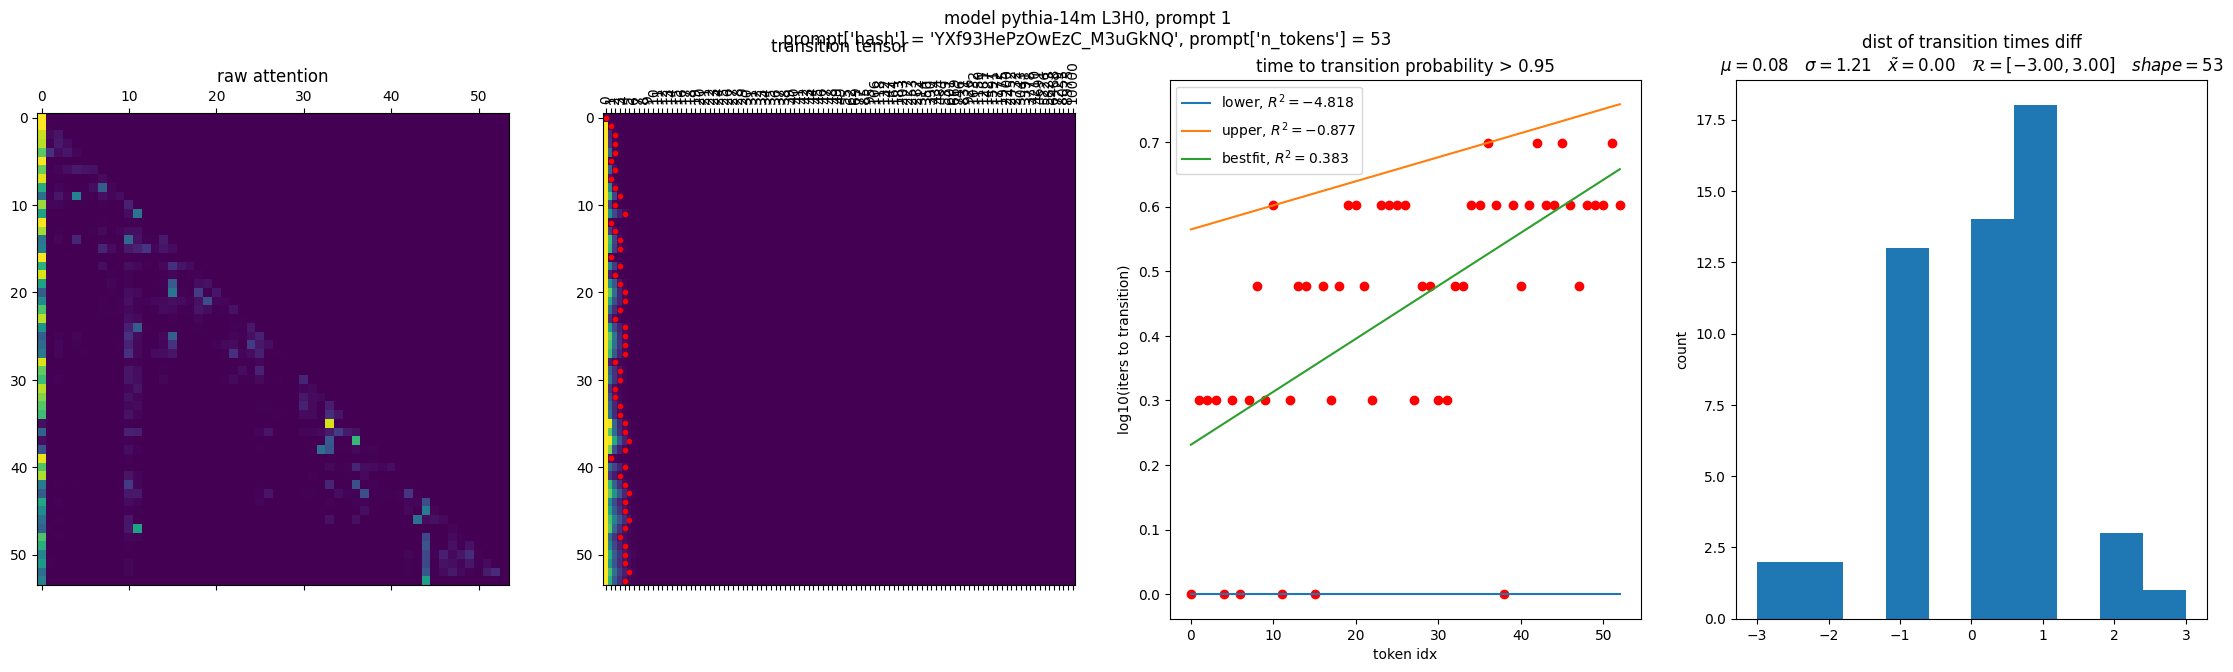

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 4, 0)
[ /home/miv/projects/attn/attention-motifs/attention_motifs/transition_tensor.py:141 ] res_resampled: μ=0.03 σ=0.20 x̃=0.00 R=[0.00,1.41] ℙ=|█▂▁▂▁▃▄| shape=(100,54) dtype=float32
[ <ipykernel>:55 ] indices_adjusted: μ=2.20 σ=0.93 x̃=2.00 R=[0.00,4.00] ℙ=|▁▆ █ ▇▄| shape=54 dtype=float64
[ <ipykernel>:56 ] indices_adjusted_l10: μ=0.31 σ=0.19 x̃=0.30 R=[0.00,0.60] ℙ=|▆  █ ▇▄| shape=53 dtype=float64


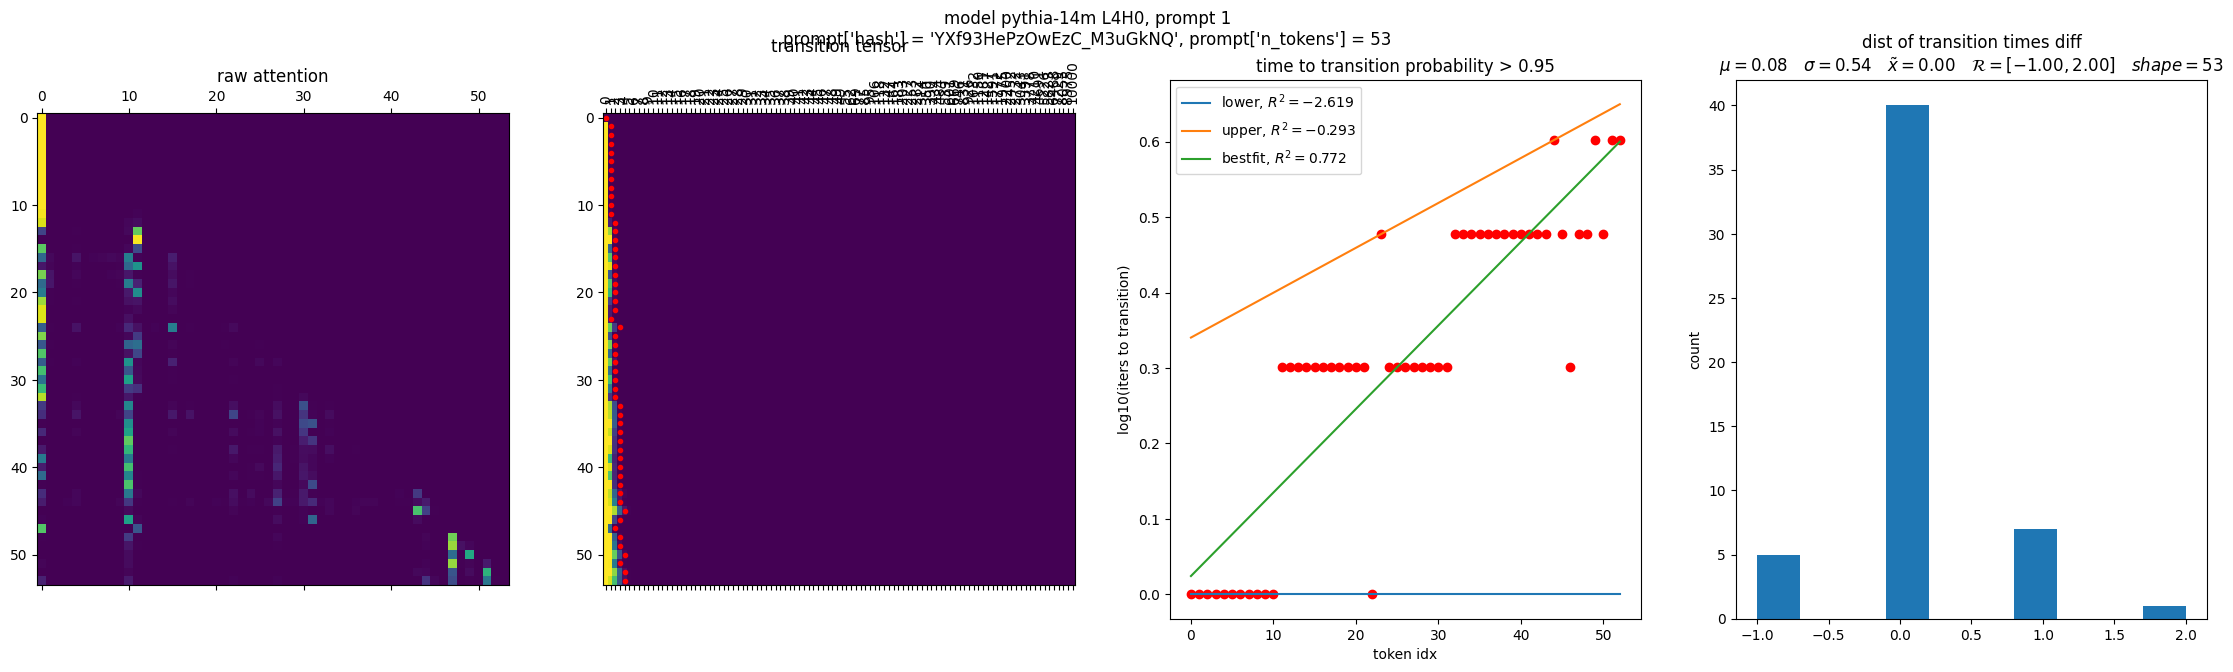

[ /home/miv/projects/attn/attention-motifs/attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 5, 0)
[ /home/miv/projects/attn/attention-motifs/attention_motifs/transition_tensor.py:141 ] res_resampled: μ=0.03 σ=0.21 x̃=0.00 R=[0.00,1.41] ℙ=|█▁ ▁▁▁▄| shape=(100,54) dtype=float32
[ <ipykernel>:55 ] indices_adjusted: μ=1.72 σ=0.95 x̃=1.00 R=[0.00,4.00] ℙ=|▁█ ▆ ▄▃| shape=54 dtype=float64
[ <ipykernel>:56 ] indices_adjusted_l10: μ=0.19 σ=0.21 x̃=0.00 R=[0.00,0.60] ℙ=|█  ▆ ▄▃| shape=53 dtype=float64


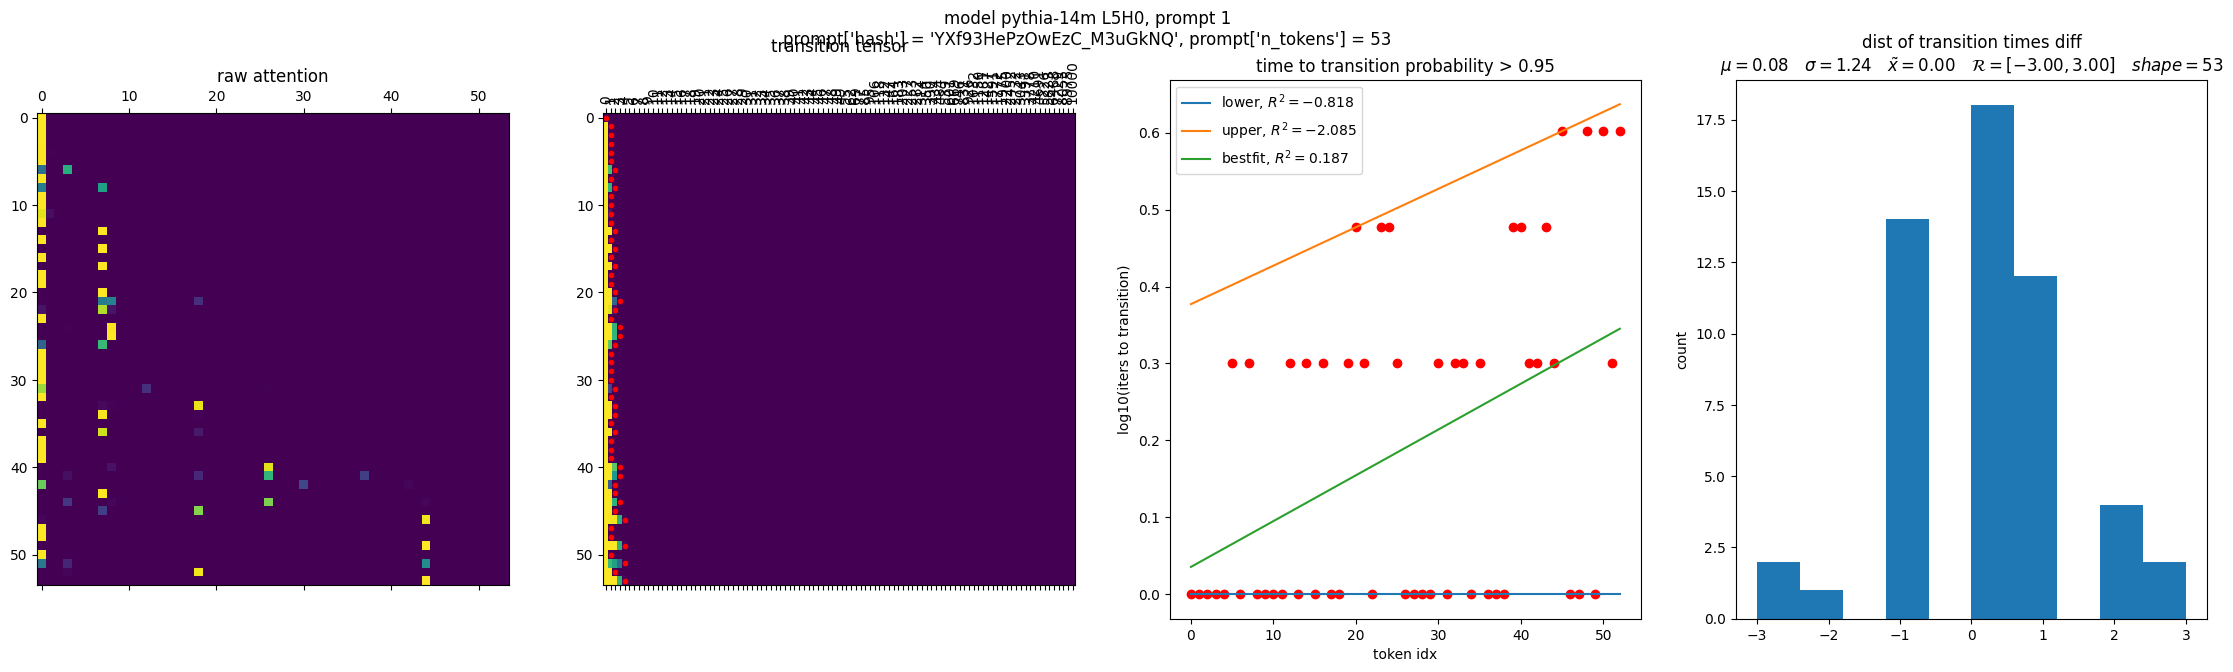

In [6]:
def fig(
	A: np.ndarray,
	axs: list[plt.Axes],
	p_idx: int,
	lyr: int,
	head: int,
	p_threshold: float = 0.95,
):
	n_ctx: int = A.shape[0]
	#
	axs[0].set_title("raw attention")
	axs[0].matshow(A)

	# compute transition_tensor
	idxs, tt, res = transition_tensor(A, exact=50, approx_l10=4.0, approx_pts=50)

	#
	axs[1].set_title("transition tensor")
	# axs[1].matshow(np.log10(1 - tt[:, :, 0].T + 1e-8), aspect=tt.shape[0] / tt.shape[1])
	# use the +1 log
	axs[1].matshow(np.log1p(1 - tt[:, :, 0].T), aspect=(tt.shape[0] / tt.shape[1]))
	axs[1].set_xticks(range(len(idxs)))
	axs[1].set_xticklabels(idxs)
	axs[1].tick_params(axis="x", rotation=90)

	#
	# axs[2].set_title("residuals tensor")
	# # aspect should be such that the image is square, although the matrix is not
	# axs[2].matshow(res.T, aspect=(res.shape[0] / res.shape[1]))
	# axs[2].set_xticks(range(len(idxs)))
	# axs[2].set_xticklabels(idxs)
	# axs[2].tick_params(axis="x", rotation=90)

	# 
	# axs[3].set_title("residuals tensor (log10)")
	# axs[3].matshow(np.log10(res.T + 1e-8), aspect=(res.shape[0] / res.shape[1]))
	# axs[3].set_xticks(range(len(idxs)))
	# axs[3].set_xticklabels(idxs)
	# axs[3].tick_params(axis="x", rotation=90)

	axs[2].set_title(f"time to transition probability > {p_threshold}")
	indices_raw = np.apply_along_axis(
		lambda row: np.searchsorted(row, p_threshold, side="right"), axis=0, arr=tt[:, :, 0]
	)
	axs[1].plot(indices_raw, np.arange(indices_raw.shape[0]), "r.")
	idxs_with_inf = np.concatenate((idxs, [1e10]))
	indices_adjusted = np.array(idxs_with_inf[indices_raw], dtype=float)
	# if last element, set to inf
	# indices_adjusted[indices_raw == len(idxs)] = 1e10
	indices_adjusted_l10 = np.log10(indices_adjusted[1:])
	axs[2].plot(indices_adjusted_l10, "ro")
	axs[2].set_xlabel("token idx")
	axs[2].set_ylabel("log10(iters to transition)")
	# axs[4].set_yscale("log")
	dbg_tensor(indices_adjusted)
	dbg_tensor(indices_adjusted_l10)
	idxs_x = np.arange(len(indices_adjusted_l10))	
	for envtype in ("lower", "upper", "bestfit"):
		env_lower = compute_envelope_params(
			x=idxs_x,
			y=indices_adjusted_l10,
			envelope_type=envtype,
		)
		axs[2].plot(
			idxs_x,
			linear(idxs_x, env_lower[0], env_lower[1]),
			label=f"{envtype}, $R^2={env_lower[2]:.3f}$",
		)
	axs[2].legend()

	indices_adjusted_diff = np.diff(indices_adjusted)
	axs[3].set_title(f"dist of transition times diff\n${array_summary(indices_adjusted_diff, fmt='latex', dtype=False)}$")
	axs[3].hist(indices_adjusted_diff, bins=10)
	axs[3].set_ylabel("count")

	# 
	# axs[5].set_title("transition time fft")
	# tt_time_fft = np.fft.fft(idxs_with_inf)
	# # print(tt_time_fft)
	# axs[5].plot(np.abs(tt_time_fft), "o-", label="abs")
	# # axs[5].plot(np.angle(tt_time_fft), label="angle")
	# # axs[5].plot(tt_time_fft.real, label="real")
	# # axs[5].plot(tt_time_fft.imag, label="imaginary")
	# axs[5].set_yscale("log")
	# axs[5].legend()



plot_figs(
	n_figures=4,
	model_cfg=MODEL_CFG,
	prompt_dicts=PROMPTS,
	activations=ACTIVATIONS,
	figure_func=fig,
	prompts=[0, 1],
	layers=None,
	heads=[0],
)

plt.show()